# ASSIGNMENT 14 - PCA

In [1]:
# Data handling libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering and evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score


In [2]:
# Load the dataset
df = pd.read_csv("wine.csv")

# Display first few rows
df.head()


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

# Dataset info
df.info()

# Statistical summary
df.describe()


Dataset Shape: (178, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [4]:
# Check missing values
df.isnull().sum()


Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

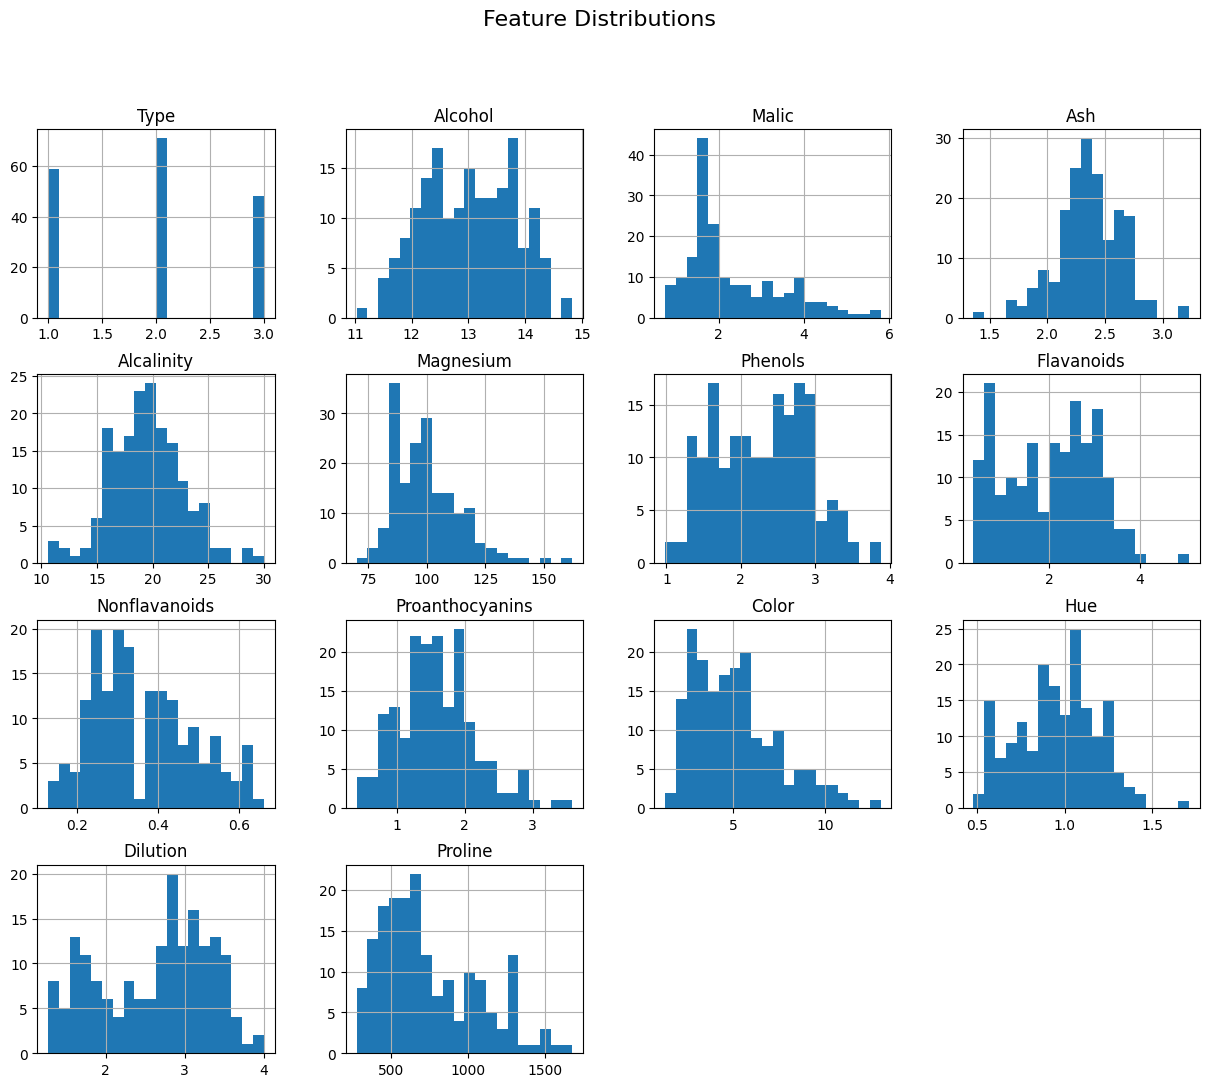

In [5]:
# Plot histograms for all features
df.hist(figsize=(15, 12), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


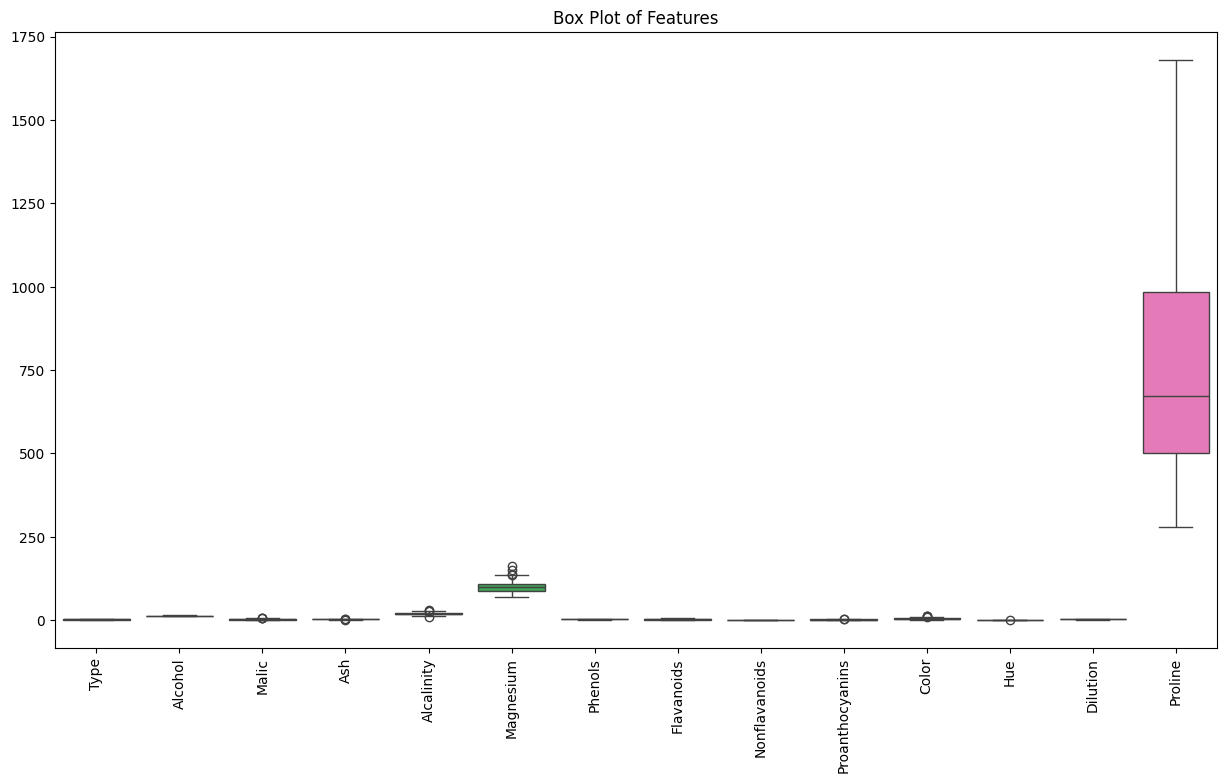

In [6]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Box Plot of Features")
plt.show()


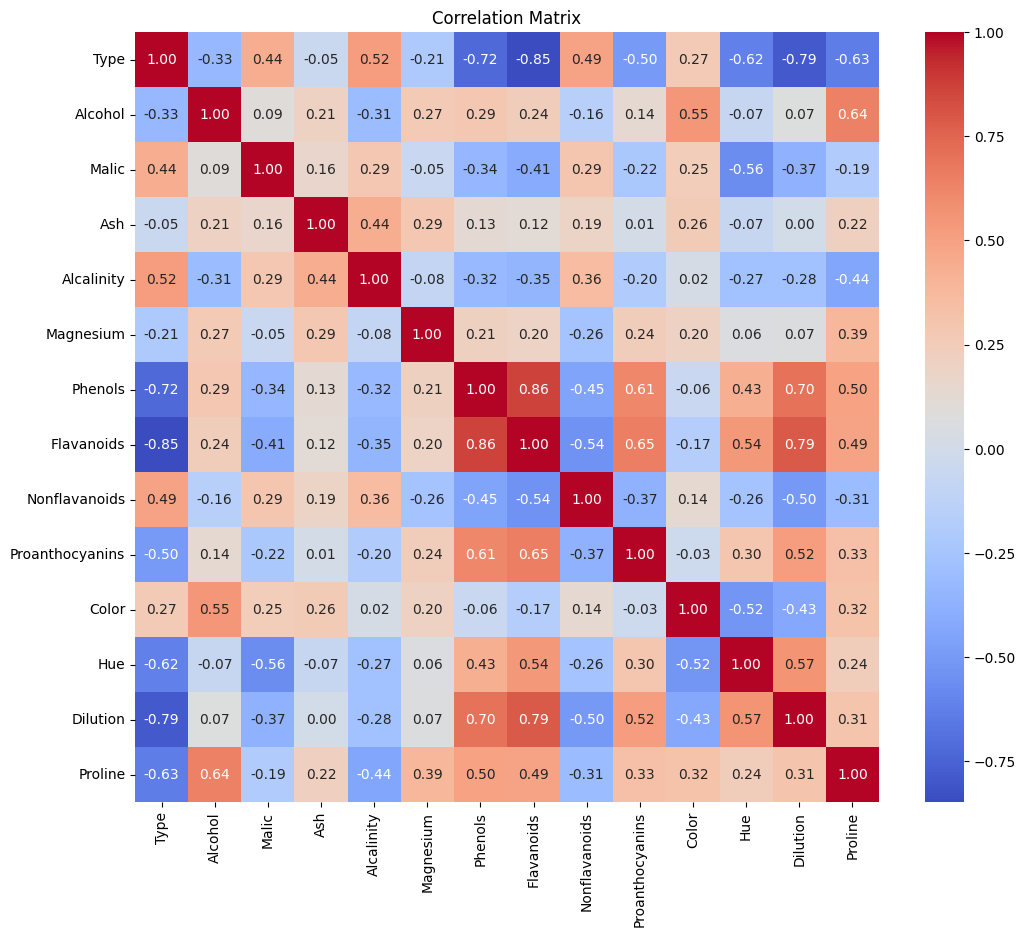

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [8]:
# Drop target column
X = df.drop("Type", axis=1)
y = df["Type"]


In [9]:
# Standardization (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [10]:
# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)


In [11]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Cumulative variance
cumulative_variance = np.cumsum(explained_variance)


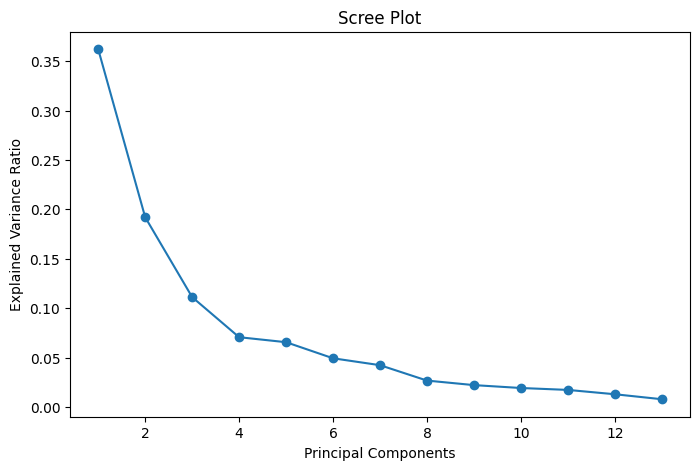

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()


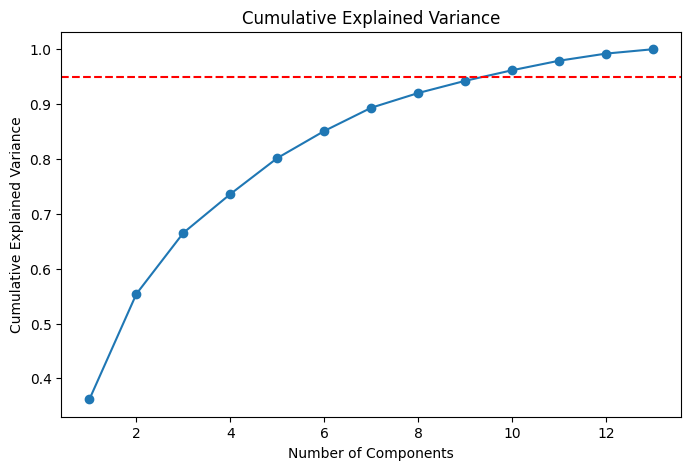

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.show()


In [14]:
# Choose 2 components
pca_final = PCA(n_components=2)
X_pca_2 = pca_final.fit_transform(X_scaled)


In [15]:
kmeans_original = KMeans(n_clusters=3, random_state=42)
labels_original = kmeans_original.fit_predict(X_scaled)


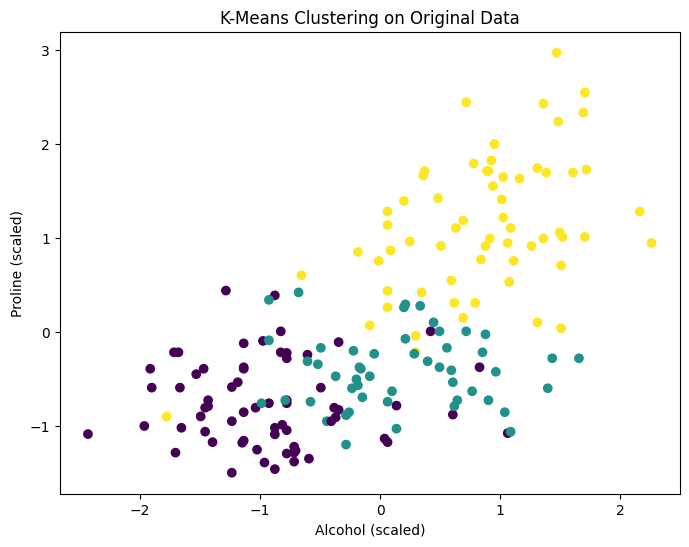

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, -1], c=labels_original)
plt.xlabel("Alcohol (scaled)")
plt.ylabel("Proline (scaled)")
plt.title("K-Means Clustering on Original Data")
plt.show()


In [17]:
silhouette_orig = silhouette_score(X_scaled, labels_original)
db_index_orig = davies_bouldin_score(X_scaled, labels_original)

print("Silhouette Score (Original):", silhouette_orig)
print("Davies-Bouldin Index (Original):", db_index_orig)


Silhouette Score (Original): 0.2848589191898987
Davies-Bouldin Index (Original): 1.3891879777181648


In [18]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca_2)


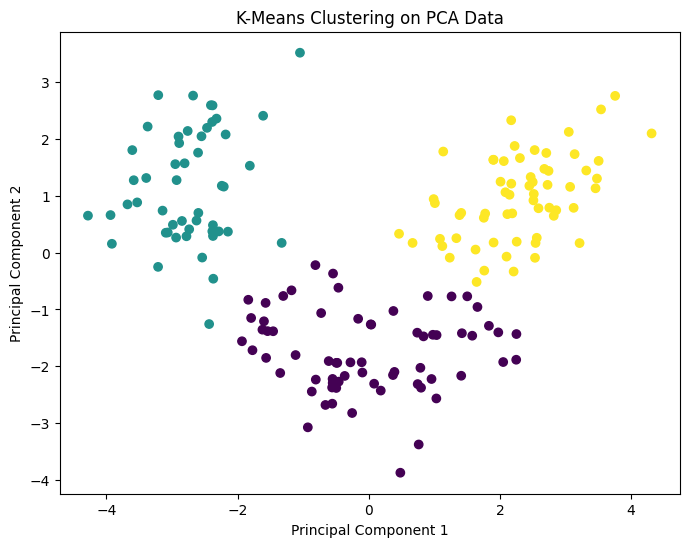

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=labels_pca)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering on PCA Data")
plt.show()


In [20]:
silhouette_pca = silhouette_score(X_pca_2, labels_pca)
db_index_pca = davies_bouldin_score(X_pca_2, labels_pca)

print("Silhouette Score (PCA):", silhouette_pca)
print("Davies-Bouldin Index (PCA):", db_index_pca)
    

Silhouette Score (PCA): 0.5601697480957203
Davies-Bouldin Index (PCA): 0.5977226208167408


In [21]:
comparison = pd.DataFrame({
    "Method": ["Original Data", "PCA Data"],
    "Silhouette Score": [silhouette_orig, silhouette_pca],
    "Davies-Bouldin Index": [db_index_orig, db_index_pca]
})

comparison


,Method,Silhouette Score,Davies-Bouldin Index
0,Original Data,0.284859,1.389188
1,PCA Data,0.560170,0.597723


# Task 6: Conclusion and Insights


1. Summary of Key Findings and Insights

In this assignment, Exploratory Data Analysis (EDA) revealed that the Wine dataset contains multiple correlated features, indicating redundancy and the presence of noise. Principal Component Analysis (PCA) was applied to reduce the dimensionality of the dataset while preserving most of the variance. Using PCA, the original 13 features were effectively reduced to 2 principal components, enabling better visualization and interpretation.

Clustering using the K-Means algorithm on the original dataset resulted in moderate cluster separation, as indicated by a lower Silhouette Score and a higher Davies–Bouldin Index. However, clustering on the PCA-transformed dataset showed a significant improvement, with a higher Silhouette Score and a lower Davies–Bouldin Index. This demonstrates that PCA-enhanced clustering produces more compact and well-separated clusters.

2. Practical Implications of Using PCA and Clustering

The combination of PCA and clustering has important practical implications in real-world data analysis. PCA helps in reducing data dimensionality, eliminating multicollinearity, and improving computational efficiency. This is especially useful when working with high-dimensional datasets where visualization and distance-based learning become challenging.

Clustering algorithms such as K-Means benefit from PCA because reduced dimensionality improves distance calculations, leading to more meaningful clusters. Additionally, PCA enables clear two-dimensional or three-dimensional visualizations, which are essential for exploratory analysis and decision-making in domains such as marketing segmentation, bioinformatics, and customer behavior analysis.

3. Recommendations Based on the Analysis

Use clustering on original data when feature interpretability is crucial and the dataset has a small number of well-defined, independent features.

Apply PCA before clustering when the dataset is high-dimensional, contains correlated features, or when visualization and improved clustering performance are required.

PCA-based clustering is recommended for distance-based algorithms such as K-Means, as it reduces noise and enhances cluster separation.

PCA should be avoided if the loss of direct feature interpretability is not acceptable for the application.

Final Insight

Overall, PCA acts as an effective preprocessing step that enhances clustering performance by simplifying the data structure without significant loss of information. The analysis clearly shows that dimensionality reduction using PCA leads to better clustering quality, making it a valuable technique in modern data analysis workflows.